将单个被试INT脑区映射到网络

In [7]:
import pandas as pd

# 读取 region246_network_Yeo 表格
region_mapping_path = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/region246_network_Yeo.csv'
region_mapping_df = pd.read_csv(region_mapping_path)

# 提取 regions 和 Yeo_7network 列，建立映射
region_to_network = region_mapping_df.set_index('regions')['Yeo_7network'].to_dict()

print('region_to_network:', region_to_network)

subtype_data_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_value/MDD_INT20.csv'
data_df = pd.read_csv(subtype_data_path)
print(data_df.shape)
subId = data_df.iloc[:, 0]

# 找到从 A8m_R 开始的列
data_of_interest = data_df.iloc[:, 1:]

# 建立 Yeo 7 网络的数据结构
network_data = {network: [] for network in set(region_to_network.values())}
print('network_data:', network_data)

# 将数据分配到对应的 Yeo 7 网络
for column in data_of_interest.columns:
    region_name = column
    if region_name in region_to_network:
        network = region_to_network[region_name]
        network_data[network].append(data_of_interest[column])

# 计算每个网络中的脑区求和和平均值
network_averages = {}
for network, data_list in network_data.items():
    print(data_list)
    if data_list:  # 确保网络中有数据
        network_df = pd.concat(data_list, axis=1)
        network_sum = network_df.sum(axis=1)
        network_mean = network_sum / len(data_list)
        network_averages[network] = network_mean

# 将结果保存为 DataFrame
result_df = pd.DataFrame(network_averages)
result_df.insert(0, 'subID', subId)

# 创建列名映射字典
column_mapping = {
    '0': 'subcortical',
    '1': 'Visual',
    '2': 'Somatomotor',
    '3': 'Dorsal Attention',
    '4': 'Ventral Attention',
    '5': 'Limbic',
    '6': 'Frontoparietal',
    '7': 'Default'
}

# 应用列名映射
result_df.columns = [column_mapping.get(str(col), col) for col in result_df.columns]

result_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_value/INT_MDD20_net7.csv'
result_df.to_csv(result_path, index=False)

print(f"计算完成，结果已保存到 {result_path}")


region_to_network: {'A8m_L': 6, 'A8m_R': 4, 'A8dl_L': 7, 'A8dl_R': 6, 'A9l_L': 7, 'A9l_R': 7, 'A6dl_L': 3, 'A6dl_R': 3, 'A6m_L': 2, 'A6m_R': 2, 'A9m_L': 7, 'A9m_R': 6, 'A10m_L': 7, 'A10m_R': 7, '46d_L': 4, '46d_R': 6, 'IFJ_L': 6, 'IFJ_R': 6, 'A46_L': 6, 'A46_R': 6, '46v_L': 6, '46v_R': 6, 'A8vl_L': 7, 'A8vl_R': 6, 'A6vl_L': 3, 'A6vl_R': 3, 'A10l_L': 5, 'A10l_R': 6, 'A44d_L': 6, 'A44d_R': 3, 'IFS_L': 6, 'IFS_R': 6, 'A45c_L': 7, 'A45c_R': 7, 'A45r_L': 7, 'A45r_R': 6, 'A44op_L': 4, 'A44op_R': 4, 'A44v_L': 4, 'A44v_R': 4, 'A14m_L': 7, 'A14m_R': 7, '47o_L': 7, '47o_R': 7, 'A11l_L': 5, 'A11l_R': 6, 'A11m_L': 5, 'A11m_R': 5, 'A13_L': 5, 'A13_R': 5, '47l_L': 7, '47l_R': 7, 'A4hf_L': 2, 'A4hf_R': 2, 'A6cdl_L': 3, 'A6cdl_R': 3, 'A4ul_L': 2, 'A4ul_R': 2, 'A4t_L': 2, 'A4t_R': 2, 'A4tl_L': 4, 'A4tl_R': 4, 'A6cvl_L': 3, 'A6cvl_R': 3, '3ll_L': 4, '3ll_R': 2, 'A4ll_L': 2, 'A4ll_R': 2, 'A38m_L': 5, 'A38m_R': 5, '42_L': 2, '42_R': 2, 'TE1.2_L': 2, 'TE1.2_R': 2, 'A22c_L': 2, 'A22c_R': 2, 'A38l_L': 5, 'A3

将一组被试INT脑区映射到网络


In [14]:
import pandas as pd

# ================== 1. 读取 Yeo 7-network 映射表 ==================
region_mapping_path = '/Users/qingchen/Documents/Data/template/BrainnetomeAtlas/region246_network_Yeo.csv'
region_mapping_df = pd.read_csv(region_mapping_path)

# 建立 脑区名称 → Yeo_7network 的映射字典
region_to_network = region_mapping_df.set_index('regions')['Yeo_7network'].to_dict()

print(f"成功加载映射表，共 {len(region_to_network)} 个脑区")

# ================== 2. 读取 INT_HC.csv 数据 ==================
subtype_data_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_value/MDD_INT202.csv'
data_df = pd.read_csv(subtype_data_path)

print(f"原始数据形状: {data_df.shape}")
print(f"被试数量: {len(data_df)}")

# subID 列（第一列）
subId = data_df.iloc[:, 0]

# 从 age 开始往后的所有列都是数据（去掉 subID）
data_of_interest = data_df.iloc[:, 1:]   # 包含 age, sex, site 等 + 所有脑区

# ================== 3. 按 Yeo 7 网络分组脑区数据 ==================
# 获取所有可能的网络名称（通常是 0~7）
networks = sorted(set(region_to_network.values()))
network_data = {net: [] for net in networks}

print("开始将脑区映射到 Yeo 7 网络...")

for col in data_of_interest.columns:
    if col in region_to_network:          # 确保是脑区列（跳过 age, sex, site 等）
        network = region_to_network[col]
        network_data[network].append(data_of_interest[col])
    # else:
    #     print(f"警告：列 {col} 不在映射表中，已跳过")

# ================== 4. 计算每个网络的平均值 ==================
network_averages = {}

for network, series_list in network_data.items():
    if series_list:
        # 把同一个网络的所有脑区列合并成一个 DataFrame
        network_df = pd.concat(series_list, axis=1)
        # 计算每个被试在该网络所有脑区的平均 INT 值
        network_mean = network_df.mean(axis=1)
        network_averages[network] = network_mean
    else:
        print(f"警告：网络 {network} 没有任何脑区")

# ================== 5. 构建结果 DataFrame 并重命名网络 ==================
result_df = pd.DataFrame(network_averages)
result_df.insert(0, 'subID', subId)

# Yeo 7 网络名称映射（根据你的 column_mapping 调整）
column_mapping = {
    0: 'subcortical',                    # 可能是不属于任何网络的区域
    1: 'Visual',
    2: 'Somatomotor',
    3: 'Dorsal_Attention',
    4: 'Ventral_Attention',
    5: 'Limbic',
    6: 'Frontoparietal',
    7: 'Default'
}

result_df.rename(columns=column_mapping, inplace=True)

# ================== 6. 保存结果 ==================
result_path = '/Volumes/QC/INT/INT_BN246_HC135BP_MDD135BP_DZIII/INT_value/MDD_INT202_7net.csv'
result_df.to_csv(result_path, index=False)

成功加载映射表，共 246 个脑区
原始数据形状: (338, 247)
被试数量: 338
开始将脑区映射到 Yeo 7 网络...


/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_8115/1331747678.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Value',


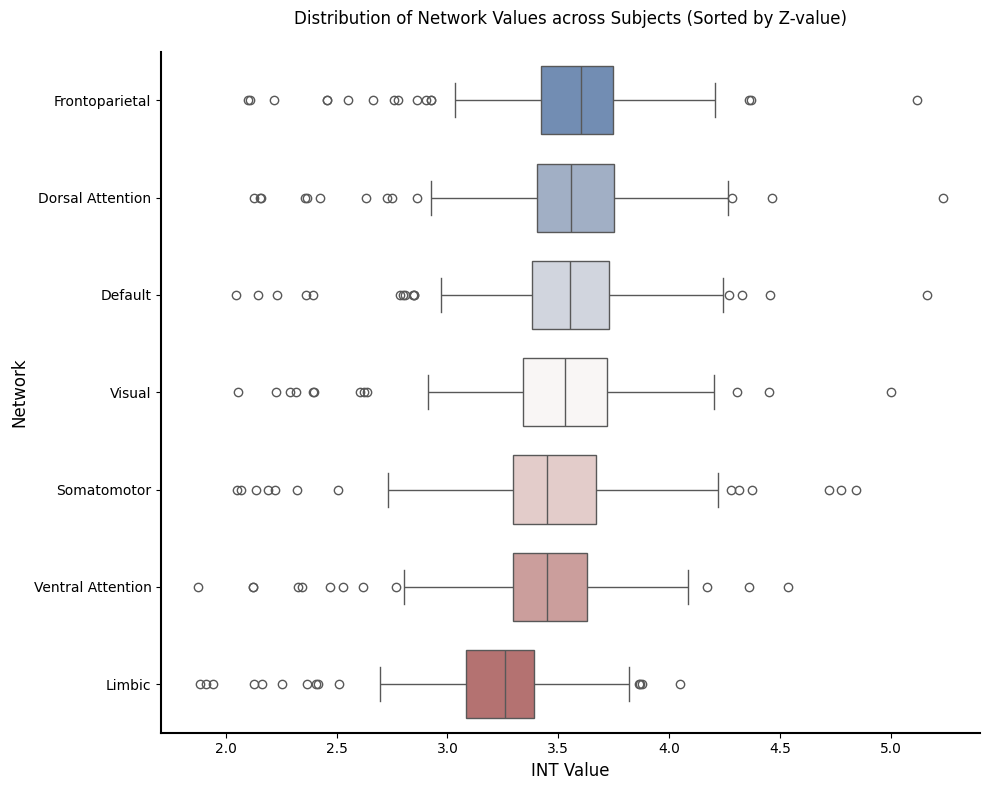

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
dpath = '/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/volume/INTvalue_HCgroup_net7.csv'
# 从 CSV 文件中读取数据
df = pd.read_csv(dpath)

# # 将数据转换为长格式
df_long = df.melt(id_vars=['subID', '0'],
                 value_vars=['Visual', 'Somatomotor', 'Dorsal Attention',
                            'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default'],
                 var_name='Network',
                 value_name='Value')

# # 将数据转换为长格式
# df_long = df.melt(id_vars=['subID'],
#                   value_vars=['DorsAttn', 'Cont', 'SalVentAttn', 'SomMot', 'Default', 'Limbic', 'Vis'],
#                   var_name='Network',
#                   value_name='Value')


# 计算每个网络的z轴值（这里假设是均值，可根据实际需求修改）
network_z_values = df_long.groupby('Network')['Value'].mean().sort_values(ascending=False)

# 获取排序后的网络顺序
network_order = network_z_values.index.tolist()

plt.figure(figsize=(10, 8))

# 绘制横向箱体图，使用排序后的网络顺序
ax = sns.boxplot(x='Value',
            y='Network',
            data=df_long,
            order=network_order,
            orient='h',
            palette='vlag',
            width=0.7)

# 设置背景颜色为透明
ax.set_facecolor('none')

# 关闭网格线显示
ax.grid(False)

# 确保坐标轴可见
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置坐标轴颜色和线宽
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# 添加标题和标签
plt.title('Distribution of Network Values across Subjects (Sorted by Z-value)', pad=20)
plt.xlabel('INT Value', fontsize=12)
plt.ylabel('Network', fontsize=12)
plt.savefig('/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/volume/7net.png', dpi=300)
# 调整布局
plt.tight_layout()
plt.show()


/var/folders/dh/dmftg40j21j249nqf2z5v2nh0000gn/T/ipykernel_8115/1643807640.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Value',


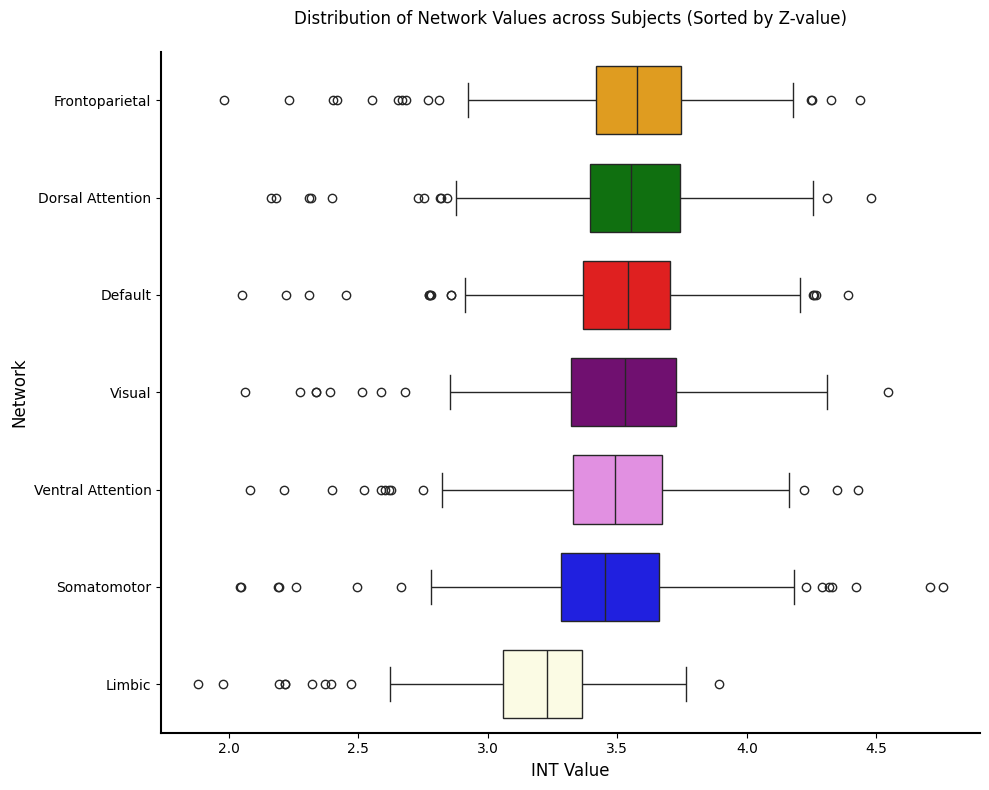

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 从 CSV 文件中读取数据
df = pd.read_csv('/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/Results/INTvalue_HCgroup_net7.csv')

# 将数据转换为长格式
df_long = df.melt(id_vars=['subID', '0'],
                 value_vars=['Visual', 'Somatomotor', 'Dorsal Attention',
                            'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default'],
                 var_name='Network',
                 value_name='Value')

# 计算每个网络的z轴值（这里假设是均值，可根据实际需求修改）
network_z_values = df_long.groupby('Network')['Value'].mean().sort_values(ascending=False)

# 获取排序后的网络顺序
network_order = network_z_values.index.tolist()

# 创建自定义颜色映射
custom_palette = {
    'Visual': 'purple',
    'Somatomotor': 'blue',
    'Dorsal Attention': 'green',
    'Ventral Attention': 'violet',
    'Limbic': 'lightyellow',
    'Frontoparietal': 'orange',
    'Default': 'red'
}

plt.figure(figsize=(10, 8))

# 绘制横向箱体图，使用排序后的网络顺序和自定义颜色
ax = sns.boxplot(x='Value',
            y='Network',
            data=df_long,
            order=network_order,
            orient='h',
            palette=custom_palette,
            width=0.7)

# 设置背景颜色为透明
ax.set_facecolor('none')

# 关闭网格线显示
ax.grid(False)

# 确保坐标轴可见
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 设置坐标轴颜色和线宽
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# 添加标题和标签
plt.title('Distribution of Network Values across Subjects (Sorted by Z-value)', pad=20)
plt.xlabel('INT Value', fontsize=12)
plt.ylabel('Network', fontsize=12)
plt.savefig('/Volumes/QC/INT/INT_BN246_HC135BP_BP135MDD/Results/7net.png', dpi=300)

# 调整布局
plt.tight_layout()
plt.show()


提取数据

In [6]:
import glob
import os
from shutil import copy
path = '/Volumes/QCII/Data135_processed/xcpd_out_mdd/xcp_d/sub-MDD*/func/*_task-rest_acq-ap_run-1_space-fsLR_atlas-4S456Parcels_den-91k_measure-pearsoncorrelation_conmat.pconn.nii'

data = glob.glob(path)

for i in data:

    subID = i.split('/')[-3]
    finame = i.split('/')[-1]

    newpth = '/Volumes/QC/Data/Schaefer400_FC/MDD_BP135/'+finame

    copy(i, newpth)



合并数据-两表相同

In [1]:
import numpy as np
import pandas as pd
file_1 ='/Volumes/QC/INT/INT_BN246_HC_MDD/INT_Results/INTvalue_MDD.csv'
file_2 ='/Volumes/QC/INT/INT_BN246_HC_MDD/INT_Results/clinicalInformation/MDD_age_sex.csv'

#Read the CSV files into DataFrames
df1 = pd.read_csv(file_1)
df2 = pd.read_csv(file_2)

df_new = pd.merge(df2, df1, on='subID', how='inner')
df_new.to_csv('/Volumes/QC/INT/INT_BN246_HC_MDD/INT_Results/INT_MDD.csv', index=False,encoding='utf-8-sig')


BLR模型结果检查-针对EXPV文件

In [5]:
import glob

import pandas as pd

path = "/Volumes/QC/INT/INT_BN246_HC_MDD/INT_NM/Results/INT246_BLR_20251111/NMResults/INT_246/*/EXPV_estimate.txt"

data = glob.glob(path)
region_values = []
for i in data:
    regionname = i.split('/')[-2]


    with open(i, 'r') as file:
        value = file.read().strip()
        # 将 regionname 和值作为一个列表添加到 region_values 中
    region_values.append([regionname, value])

df = pd.DataFrame(region_values, columns=['RegionName', 'EXPV'])
csv_path = "./expv.csv"
df.to_csv(csv_path, index=False)

GPR模型结果检查

In [7]:
import pandas as pd
import numpy as np

def pkltocsv(Resultpath,labelpath,columnsname,opath,mark):
    Rho_AllHCestimate = pd.read_pickle(Resultpath+'Rho_'+mark+'.pkl')
    print(Rho_AllHCestimate.shape)
    pRho_AllHCestimate = pd.read_pickle(Resultpath+'pRho_'+mark+'.pkl')
    print(pRho_AllHCestimate.shape)
    SMSE_AllHCestimate = pd.read_pickle(Resultpath+'SMSE_'+mark+'.pkl')
    print(SMSE_AllHCestimate.shape)
    RMSE_AllHCestimate = pd.read_pickle(Resultpath+'RMSE_'+mark+'.pkl')
    print(RMSE_AllHCestimate.shape)
    yhat_AllHCestimate = pd.read_pickle(Resultpath+'yhat_'+mark+'.pkl')
    print(yhat_AllHCestimate.shape)
    EXPV_AllHCestimate = pd.read_pickle(Resultpath + 'EXPV_' + mark + '.pkl')
    print(EXPV_AllHCestimate.shape)
    MSLL_AllHCestimate = pd.read_pickle(Resultpath + 'MSLL_' + mark + '.pkl')

    label = pd.read_csv(labelpath)
    brainRegion = label.columns.tolist()
    a = brainRegion[4:]
    regions = pd.DataFrame(a)


    df_sum = pd.concat([regions, Rho_AllHCestimate, pRho_AllHCestimate, RMSE_AllHCestimate, SMSE_AllHCestimate, EXPV_AllHCestimate,MSLL_AllHCestimate],
                       axis=1)  # 将两列拼接在一起，axis=1 表示按列拼接
    df_sum.columns = columnsname
    df_sum.to_csv(opath)
columnsname = ['Regions','Rho', 'pRho', 'RMSE', 'SMSE', 'EXPV','MSLL']

Resultpath = '/Volumes/QC/INT/INT_BN246_HC_MDD/INT_NM/Results/INT246_GPR_20251112/NMResults/'
labelpath = '/Volumes/QC/INT/INT_BN246_HC_MDD/INT_NM/Feature/HC_Train_harmonized.csv'
opath = '/Volumes/QC/INT/INT_BN246_HC_MDD/INT_NM/Results/INT246_GPR_20251112/NMResults/GPR_GrayVol246_HC_Discover_ResSum.csv'
mark = 'Test'
pkltocsv(Resultpath,labelpath,columnsname,opath,mark)
#
# Resultpath = '/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_10K_HCMDD_1022/NMResults/'
# mddlabel = '/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_10K_HCMDD_1022/NMResults/allMDD_GrayVol246_combat_final.csv'
# opath = '/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_10K_HCMDD_1022/StaResults/GPR_GrayVol246_MDD_ResSum.csv'
# mark = 'AllMDD'
# pkltocsv(Resultpath,mddlabel,columnsname,opath,mark)

(246, 1)
(246, 1)
(246, 1)
(246, 1)
(1088, 246)
(246, 1)


GPR模型提前 z值

In [ ]:
import pandas as pd

Z_AllHCestimate = pd.read_pickle('/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_5K_HCMDD_1022/NMResults/Z_AllHCestimate.pkl')
#Z_AllHCestimate = pd.read_pickle('/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_5K_HCMDD_1022/NMResults/Z_AllMDD.pkl')
label = pd.read_csv('/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_5K_HCMDD_1022/NMResults/allHC_GrayVol246_combat_final.csv')

brainRegion = label.columns.tolist()
del brainRegion[0:7]


Z_AllHCestimate.columns = brainRegion

subIDs = label['subID']

zvalue = pd.concat([subIDs, Z_AllHCestimate], axis=1)

zvalue.to_csv('/Volumes/QCI/NormativeModel/Results/Result_GrayVol246_GPH_5K_HCMDD_1022/StaResults/GrayVol246_Z_AllHCestimate.csv')

In [6]:
import nibabel as nib

da = nib.load("/Volumes/QC/Data/INT/brianproject/HC/sub-01000018V01_task-rest_acq-ap_run-1_space-fsLR_den-91k_bold_smooth.dtseries.nii").get_fdata()
print(da.shape)

(240, 91282)
